**Visualize BAM file alignment at the Leptin gene locus:**

First download the reference genome.

This file contains the entire mouse genome DNA sequence (chromosomes).

In [2]:
%%bash

REFDIR="ftp://ftp.ensembl.org/pub/release-97/fasta/mus_musculus/dna/Mus_musculus.GRCm38.dna.primary_assembly.fa.gz"
OUTDIR="/var/www/html/usb/jupyter/my_projects/reference_genomes/mus_musculus/dna"

mkdir -p "$OUTDIR" && wget -q -P "$OUTDIR" "$REFDIR"
echo "Download complete"

--2026-05-15 10:40:55--  ftp://ftp.ensembl.org/pub/release-97/fasta/mus_musculus/dna/Mus_musculus.GRCm38.dna.primary_assembly.fa.gz
           => ‘/var/www/html/usb/jupyter/my_projects/reference_genomes/mus_musculus/dna/Mus_musculus.GRCm38.dna.primary_assembly.fa.gz’
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /pub/release-97/fasta/mus_musculus/dna ... done.
==> SIZE Mus_musculus.GRCm38.dna.primary_assembly.fa.gz ... 805984352
==> PASV ... done.    ==> RETR Mus_musculus.GRCm38.dna.primary_assembly.fa.gz ... done.
Length: 805984352 (769M) (unauthoritative)

     0K .......... .......... .......... .......... ..........  0% 1.12M 11m28s
    50K .......... .......... .......... .......... ..........  0% 3.10M 7m48s
   100K .......... .......... .......... .......... ..........  0%

**Decompress the genome:**

In [3]:
%%bash

REFDIR="/var/www/html/usb/jupyter/my_projects/reference_genomes/mus_musculus/dna"

gzip -d "$REFDIR"/Mus_musculus.GRCm38.dna.primary_assembly.fa.gz

echo "unzip complete"

unzip complete


**Use the Python package genomeview to visualize our BAM alignments:**

In [16]:
import genomeview

# only one dataset is shown here but you can put multiple datasets below to visualise:
#datasets = {"High-Fat Diet Control 1":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017133_quant/pseudoalignments.bam"}

datasets = {
            "High-Fat Diet Control 1":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017135_quant/pseudoalignments.bam",
            "High-Fat Diet Control 2":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017137_quant/pseudoalignments.bam",
            "High-Fat Diet Control 3":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017133_quant/pseudoalignments.bam",
            "High-Fat Diet Tumor 1":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017132_quant/pseudoalignments.bam",
            "High-Fat Diet Tumor 2":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017128_quant/pseudoalignments.bam",
            "High-Fat Diet Tumor 3":"/var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017138_quant/pseudoalignments.bam"
           }

reference = "/var/www/html/usb/jupyter/my_projects/reference_genomes/mus_musculus/dna/Mus_musculus.GRCm38.dna.primary_assembly.fa"
chrom = "chr6"
start = 29060195 
end = 29073877
visualization = genomeview.visualize_data(datasets, chrom, start, end, reference)

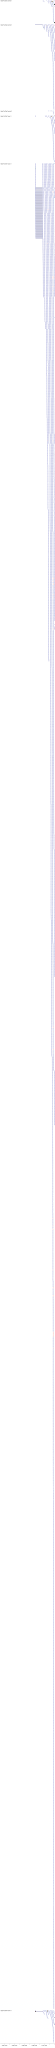

In [17]:
visualization

**Visualizing at UCSC Genome Browse:**

Note: this example assumes you have your own public domain name which is pointing at your Raspberry Pi BAM folder.

If you dont have your own public domain name, as an alternative you can copy your BAM files from your Raspberry Pi to your PC and then upload them to the genome browser website. They are large files, which is why this method is nicer than copying them to your PC, because with this method the BAM files upload from your Raspberry Pi to the Genome Browser website directly.

Create a BAM index file for each sample (note: only one sample is shown below)

In [18]:
%%bash

# For one file only:
# samtools index /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017135.fastq.gz_quant/pseudoalignments.bam

# For multiple files:
for bam in /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/*/pseudoalignments.bam
do
    echo "Indexing $bam"
    samtools index "$bam"
done

echo "Finished."

Indexing /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017128_quant/pseudoalignments.bam
Indexing /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017132_quant/pseudoalignments.bam
Indexing /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017133_quant/pseudoalignments.bam
Indexing /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017135_quant/pseudoalignments.bam
Indexing /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017137_quant/pseudoalignments.bam
Indexing /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017138_quant/pseudoalignments.bam
Finished.


**Create new folders outside of Jupyter:**

Create a separate public folder outside the Jupyter proxy path because the jupyter folder on the Ras Pi isnt accessable by genome browser website:

In [6]:
# For testing, make one dir:
# mkdir -p /var/www/html/usb/genome_browser/bamfiles/SRR5017135

In [ ]:
# For testing copy the BAM file and BAM index file to the new publically accessable folder:
# cp /var/www/html/usb/jupyter/my_projects/kallisto/analyzed/SRR5017135.fastq.gz_quant/pseudoalignments.bam* /var/www/html/usb/genome_browser/bamfiles/SRR5017135

In [19]:
%%bash

SOURCE=/var/www/html/usb/jupyter/my_projects/kallisto/analyzed
DEST=/var/www/html/usb/genome_browser/bamfiles

for dir in "$SOURCE"/*_quant
do
    sample=$(basename "$dir" .fastq.gz_quant)

    mkdir -p "$DEST/$sample"

    cp "$dir"/pseudoalignments.bam* "$DEST/$sample/"

    echo "Copied $sample"
done

Copied SRR5017128_quant
Copied SRR5017132_quant
Copied SRR5017133_quant
Copied SRR5017135_quant
Copied SRR5017137_quant
Copied SRR5017138_quant


Copy the BAM file and BAM index file to the new publically accessable folder:

Setup your public domain name to point to the /usb/genome_browser folder. In this example the public domain name is regmedweb.com which has a tunnel to the folder /usb/genome_browser

Go to the website https://genome-euro.ucsc.edu/cgi-bin/hgGateway

Click on 'Mouse'

Type "Lep" into the "Position/Search Term" field

Click on the "Add custom tracks" button

Copy and paste the code from below, under the UCSC Formatted Genome Browser BAM URL

track name="High-FatCntl_1" type=bam bigDataUrl=https://regmedweb.com/usb/genome_browser/bamfiles/SRR5017135_quant/pseudoalignments.bam

track name="High-FatCntl_2" type=bam bigDataUrl=https://regmedweb.com/usb/genome_browser/bamfiles/SRR5017137_quant/pseudoalignments.bam

track name="High-FatCntl_3" type=bam bigDataUrl=https://regmedweb.com/usb/genome_browser/bamfiles/SRR5017133_quant/pseudoalignments.bam

track name="High-FatTumor_1" type=bam bigDataUrl=https://regmedweb.com/usb/genome_browser/bamfiles/SRR5017132_quant/pseudoalignments.bam

track name="High-FatTumor_2" type=bam bigDataUrl=https://regmedweb.com/usb/genome_browser/bamfiles/SRR5017128_quant/pseudoalignments.bam

track name="High-FatTumor_3" type=bam bigDataUrl=https://regmedweb.com/usb/genome_browser/bamfiles/SRR5017138_quant/pseudoalignments.bam

Click 'Submit' button on the 'Add Custom Tracks' webpage

Click 'Go to first annotation' button

Unser the 'Visible Tracks' banner, you should see your sample names with a dropdown menu showing 'Dense' option. You need to change it to 'Squish' for each of your sample names, then click on 'Refresh' button to the right of the 'Visible Tracks' banner. 

In [ ]:
Now your transcripts should be displayed above the mouse transcriptome, you can scroll down to see the mouse transcriptome below your transcript samples. 